In [60]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

import nest_asyncio
nest_asyncio.apply()

import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = "vscode"            

import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
import matplotlib.dates as mdates
plt.style.use('ggplot')
params = {'legend.fontsize': 'x-large',
        'figure.figsize': (12, 8),
        'axes.labelsize': 'x-large',
        'axes.titlesize':'x-large',
        'xtick.labelsize':'x-large',
        'ytick.labelsize':'x-large'}
pylab.rcParams.update(params)

import pandas as pd
import numpy as np
import rateslib as rl
import QuantLib as ql

import datetime
import pytz

NYC_tz = pytz.timezone("America/New_York") 

import sys
sys.path.append("../../")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [61]:
from MDP.STIRFutures.STIRFutureOptionMDP import STIRFutureOptionMDP
from Query.STIRFutureOptions.STIRFutureOptionQuery import STIRFutureOptionQuery
from Query.STIRFutureOptions.STIRFutureOptionStructure import STIRFutureOptionStructure
from Query.STIRFutureOptions.STIRFutureOptionValue import STIRFutureOptionValue

In [62]:
stirfo_mdp = STIRFutureOptionMDP(source="BARCHART_STIRFO-QL")

In [10]:
as_of = datetime.date(2026, 5, 22)
# as_of = "live"

q = STIRFutureOptionQuery(
    structure=STIRFutureOptionStructure.OUTRIGHT,
    value=STIRFutureOptionValue.PRICE,
    symbol="SFRZ26|25DC",  
    market_request={
        "endpoint": "option_snapshot",
        "timestamp": as_of,
        "use_ql_calculator": True,
        # "force_refresh": True,
    },
)

req = q.build_mdp_request(as_of)
pr = stirfo_mdp.get_pricer(req)

package, weights = q.resolve_package(pricer_or_curve=pr)
value_map = q.build_value_map(
    pricer_or_curve=pr,
    package=package,
    risk_weights=weights,
)

print("resolved_symbol:", package[0].symbol())
print("price:", value_map.apply(STIRFutureOptionValue.PRICE))
print("iv_normal_bps:", value_map.apply(STIRFutureOptionValue.IV_NORMAL_BPS))
print("delta:", value_map.apply(STIRFutureOptionValue.DELTA))
print("gamma:", value_map.apply(STIRFutureOptionValue.GAMMA))
print("vega:", value_map.apply(STIRFutureOptionValue.VEGA))
print("theta:", value_map.apply(STIRFutureOptionValue.THETA))

resolved_symbol: SFRZ26|9643C
price: 0.095
iv_normal_bps: 80.78231472139129
delta: 0.25699856803023313
gamma: 0.5232516940544643
vega: 0.24087814985596298
theta: -0.16715414557570601


In [14]:
from RVUtils.ImpliedDistribution import (
    SFRImpliedDistribution,
    FedScenarioConfig,
    plot_snapshot_dashboard,
    plot_rnd_comparison,
	plot_distribution_change,
	resolve_strip_symbols,
    plot_strip_distribution_change,
    plot_sfr_smile
)


# config = FedScenarioConfig.default_sofr_scenarios(
#     current_rate=3.64, n_cuts_range=[-1, 0, 1, 2, 3]
# )
# dist = SFRImpliedDistribution(scenario_config=config)

# smile1 = stirfo_mdp.fetch_sabr_smile({
#     "symbol": "SFRZ26",
#     "as_of": datetime.date(2026, 5, 22),
#     # "strike_offsets_bps": "listed",
#     # "force_refresh": True,
#     "show_tqdm": True,
# })
# plot_sfr_smile(smile1)

# smile2 = stirfo_mdp.fetch_sabr_smile({
#     "symbol": "SFRM27",
#     "as_of": datetime.date(2026, 3, 3),
#     # "as_of": "live", 
#     # "strike_offsets_bps": "listed",
#     "show_tqdm": True,
# })
# plot_sfr_smile(smile2)

# snap_before, snap_after = dist.compare(smile1, smile2)
# fig = plot_distribution_change(snap_before, snap_after)

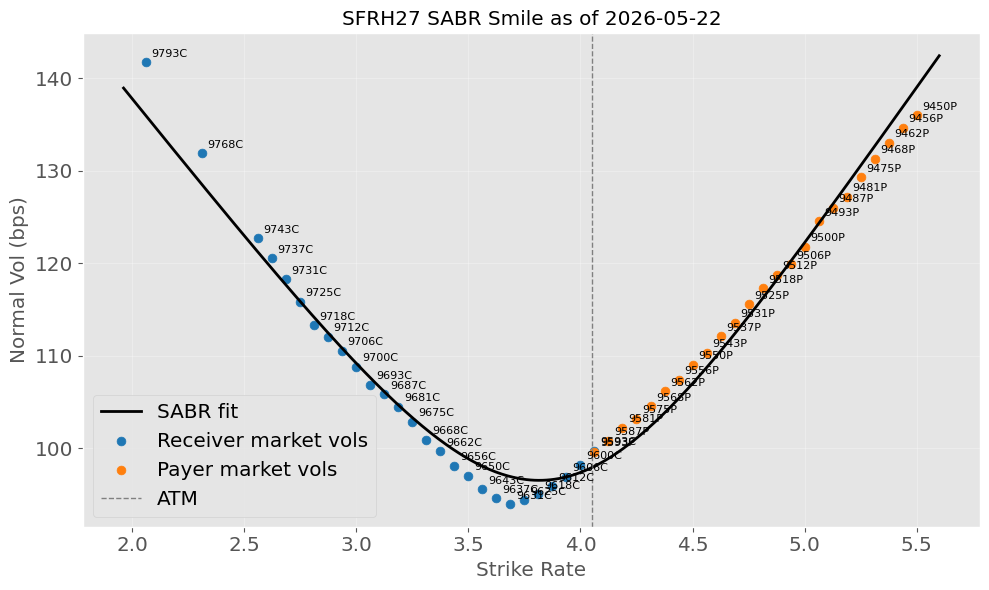

TypeError: ImpliedDistributionSnapshot.__init__() got an unexpected keyword argument 'bkm_result'. Did you mean 'bl_result'?

In [63]:
from RVUtils.ImpliedDistribution import SFRImpliedDistribution, plot_snapshot_dashboard

smile = stirfo_mdp.fetch_sabr_smile({
    "symbol": "SFRH27",
    "as_of": datetime.date(2026, 5, 22),
    "strike_offsets_bps": "listed",
    "show_tqdm": True,
})
plot_sfr_smile(smile)

# Default is raw JPM-style BL:
# observed OTM premiums, OI >= 100, put-call parity, 25bp bins
dist = SFRImpliedDistribution()

snapshot = dist.extract(smile)
bl = snapshot.bl_result

print("mean:", bl.mean_rate)
print("median:", bl.percentile(50))
print("5th:", bl.percentile(5))
print("95th:", bl.percentile(95))
print("bin edges:", bl.bin_edges_rate)
print("bin probabilities:", bl.bin_probabilities)

a = plot_snapshot_dashboard(snapshot)

In [42]:
bl.percentile(95)

4.6151735072297395